# Predicting Mumbai's Seasonal Rainfall Total
### A Mid-Season Monsoon Forecast Update Model (1901–2021)

**Objective:** Build a model that, using rainfall already observed by the end of August, predicts the **final annual rainfall total** for Mumbai — the kind of mid-season forecast revision that water utilities and reservoir managers use to update supply planning as the monsoon progresses.

**Data source:** Mumbai monthly rainfall, 1901–2021 (data.opencity.in). 121 years, 12 monthly columns (mm) + annual Total.

This notebook explicitly incorporates lessons from prior project feedback:
- Time-series lag/rolling features are built with `.shift()` so **no future information leaks into the past** — verified in a dedicated cell.
- Train/test split is **chronological**, not random (data is a time series).
- Cross-validation uses **`TimeSeriesSplit`**, not ordinary K-Fold.
- Hyperparameter tuning uses a **wider grid** than a previous project's `n_iter=5`, and explicitly discusses cases where tuning does **not** help.
- The winning model is chosen strictly from **CV + test metrics**, never by default preference for a "fancier" algorithm.
- Includes residual diagnostics, error analysis by year, SHAP explainability, and a business-impact translation.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
import xgboost as xgb
import lightgbm as lgb
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
pd.set_option('display.width', 120)

C:\Users\shivj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [2]:
df = pd.read_csv("mumbai-monthly-rains.csv")
df = df.sort_values('Year').reset_index(drop=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (121, 14)

Columns: ['Year', 'Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Total']


,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


### Insight
121 rows, one per year from 1901–2021, with 12 monthly rainfall columns (mm) plus a `Total` column. This is a genuinely small dataset by ML standards, which shapes several downstream decisions: prefer simpler models, use cross-validation rather than a single lucky split, and be conservative about how much signal we claim to find.

### Data Quality Check

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Year range:", df['Year'].min(), "-", df['Year'].max())
print("Any gap years?", sorted(set(range(df['Year'].min(), df['Year'].max()+1)) - set(df['Year'])))

# Sanity check: do monthly columns actually sum to Total?
month_cols = ['Jan','Feb','Mar','April','May','June','July','Aug','Sept','Oct','Nov','Dec']
recomputed_total = df[month_cols].sum(axis=1)
print("Max |Total - sum(months)| discrepancy:", (df['Total'] - recomputed_total).abs().max())

df.describe().T

Missing values: 0
Duplicate rows: 0
Year range: 1901 - 2021
Any gap years? []
Max |Total - sum(months)| discrepancy: 4.990001798432786e-07


,count,mean,std,min,25%,50%,75%,max
Year,121.0,1961.000000,35.073732,1901.000000,1931.000000,1961.000000,1991.000000,2021.000000
Jan,121.0,1.567235,6.462247,0.000000,0.000000,0.000000,0.000000,51.348290
Feb,121.0,0.929358,3.077050,0.000000,0.000000,0.000000,0.152298,21.107118
Mar,121.0,0.869231,2.890032,0.000000,0.000000,0.000000,0.000000,18.252996
April,121.0,1.428458,7.371307,0.000000,0.000000,0.000000,0.194165,75.541818
May,121.0,18.183632,48.628812,0.000000,0.000000,0.355001,4.208322,234.392757
June,121.0,517.854402,251.067016,61.058662,324.094617,482.449872,678.040770,1219.518576
July,121.0,757.407412,285.836188,103.209194,540.745923,788.403637,942.616099,1358.833554
Aug,121.0,465.600818,249.072915,87.493370,268.002392,445.870342,604.372615,1200.956558
Sept,121.0,312.885747,205.135368,36.313545,149.584208,269.276549,398.645218,987.796660


In [4]:
df['Total'] - recomputed_total

0      2.299976e-08
1      8.200027e-08
2      2.259999e-07
3      3.500004e-07
4     -2.220002e-07
           ...     
116    2.229999e-07
117    4.070002e-07
118   -1.839999e-07
119   -1.210001e-07
120   -2.160000e-07
Length: 121, dtype: float64

### Insight
No missing values, no duplicate rows, and no gap years — the series is a complete, continuous 121-year record. The recomputed monthly sum matches `Total` almost exactly (discrepancy < 0.01mm, floating-point rounding only), confirming `Total` is derived directly from the monthly columns rather than an independently reported figure — important to know before engineering features from it.

## 3. Exploratory Data Analysis

### 3.1 Distribution of Annual Total Rainfall

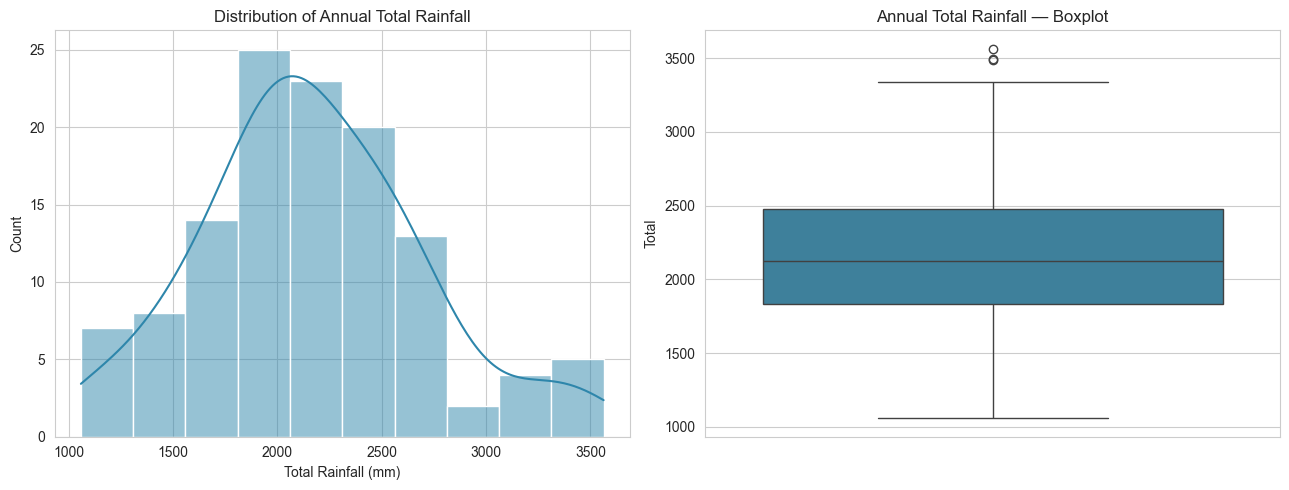

Skewness: 0.35
Min / Median / Max: 1059.0 2126.0 3563.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['Total'], kde=True, ax=axes[0], color='#2E86AB')
axes[0].set_title('Distribution of Annual Total Rainfall')
axes[0].set_xlabel('Total Rainfall (mm)')

sns.boxplot(y=df['Total'], ax=axes[1], color='#2E86AB')
axes[1].set_title('Annual Total Rainfall — Boxplot')
plt.tight_layout()
plt.show()

print("Skewness:", round(df['Total'].skew(), 2))
print("Min / Median / Max:", df['Total'].min().round(0), df['Total'].median().round(0), df['Total'].max().round(0))

### Insight
Annual totals range from about 1,059mm to 3,563mm with a mild right skew (skew ≈ 0.35) — a handful of unusually wet years stretch the upper tail, but there are no extreme outliers that look like data-entry errors. No transformation is strictly necessary, though this mild skew is one more reason to prefer models (linear or tree-based) that don't assume strict normality.

### 3.2 Long-Term Trend

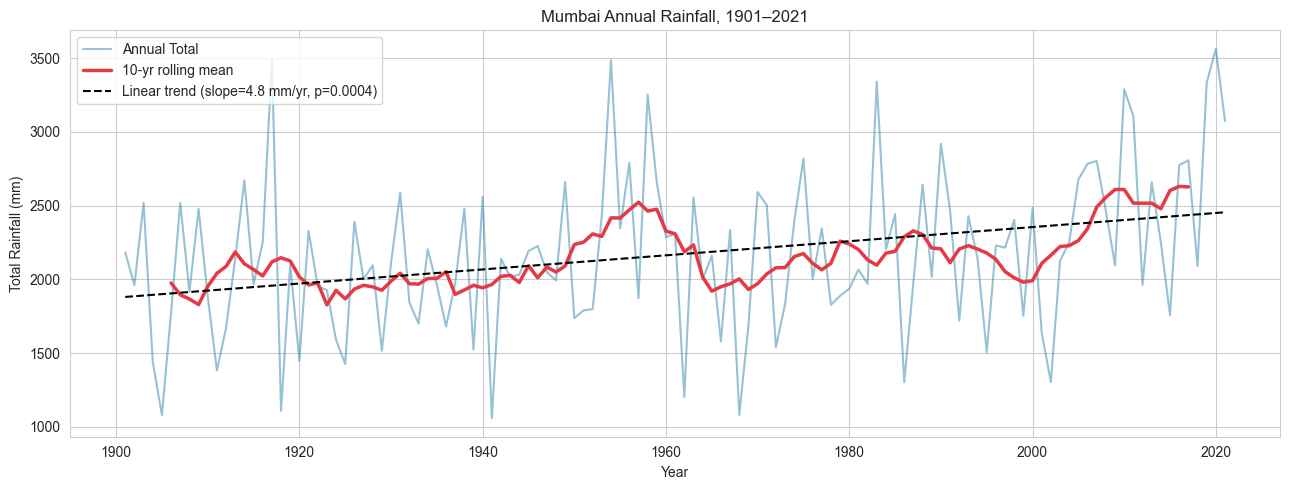

Trend: 4.78 mm/year, r=0.315, p-value=0.00044


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['Year'], df['Total'], color='#2E86AB', alpha=0.5, label='Annual Total')
ax.plot(df['Year'], df['Total'].rolling(10, center=True).mean(), color='#E63946', linewidth=2.5, label='10-yr rolling mean')

slope, intercept, r, p, se = stats.linregress(df['Year'], df['Total'])
ax.plot(df['Year'], intercept + slope*df['Year'], color='black', linestyle='--', linewidth=1.5,
        label=f'Linear trend (slope={slope:.1f} mm/yr, p={p:.4f})')
ax.set_title('Mumbai Annual Rainfall, 1901–2021')
ax.set_xlabel('Year'); ax.set_ylabel('Total Rainfall (mm)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trend: {slope:.2f} mm/year, r={r:.3f}, p-value={p:.5f}")

### Insight
There is a statistically significant upward trend (~4.8mm/year, p<0.001), though the trend line only explains about 10% of year-to-year variance (r≈0.31) — rainfall is noisy around a slowly rising baseline. The 10-year rolling mean shows this isn't a smooth climb: it's flat-to-declining through the mid-20th century, then rises noticeably from the 2000s onward, most sharply in the 2010s. This long-term drift is real signal worth including as a feature, but it is not, by itself, a useful predictor of any single year's rainfall.

### 3.3 Decadal Averages

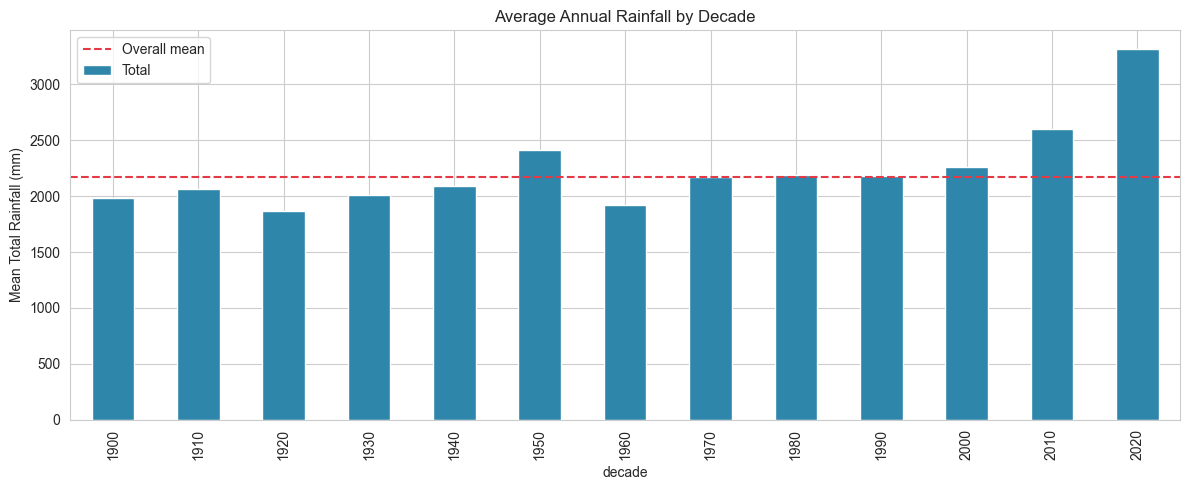

decade
1900    1986.0
1910    2068.0
1920    1868.0
1930    2007.0
1940    2093.0
1950    2416.0
1960    1920.0
1970    2175.0
1980    2191.0
1990    2179.0
2000    2263.0
2010    2603.0
2020    3319.0
Name: Total, dtype: float64

In [7]:
df['decade'] = (df['Year'] // 10) * 10
decade_avg = df.groupby('decade')['Total'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
decade_avg.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title('Average Annual Rainfall by Decade')
ax.set_ylabel('Mean Total Rainfall (mm)')
ax.axhline(df['Total'].mean(), color='#E63946', linestyle='--', label='Overall mean')
ax.legend()
plt.tight_layout()
plt.show()
decade_avg.round(0)

### Insight
The 2010s (2,603mm) and 2020s-so-far (3,319mm, only 2 years) stand well above the 120-year average (~2,168mm), consistent with the upward trend detected above. The 1920s and 1960s were the driest decades on record. This is useful context for stakeholders but, again, decade-level averages smooth over the large individual-year swings that actually matter for operational forecasting.

### 3.4 Monthly Rainfall Pattern & Monsoon Dominance

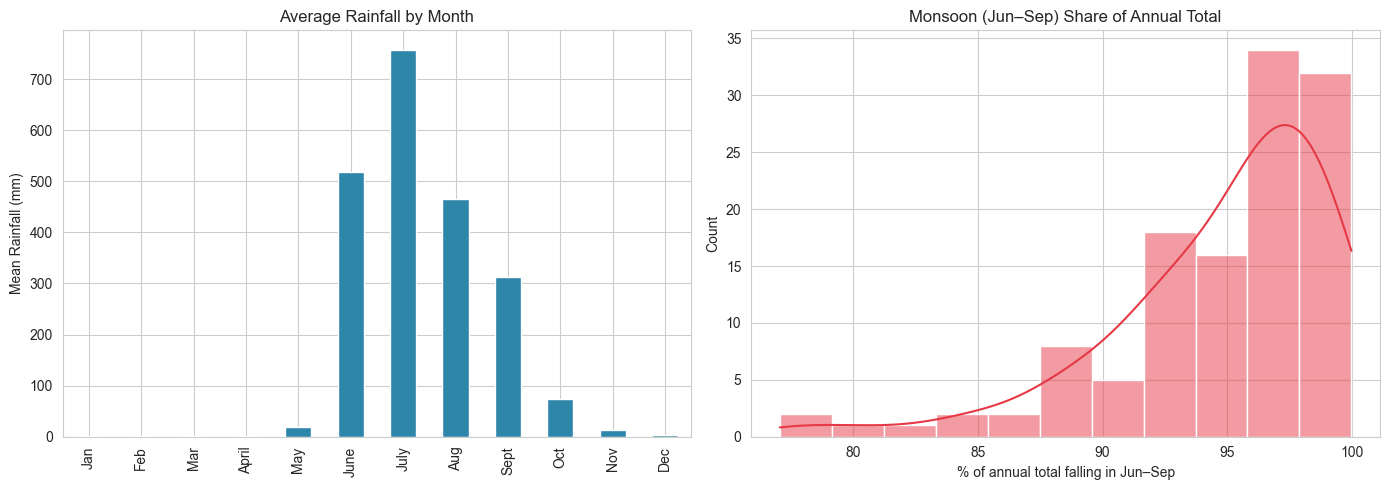

Monsoon (Jun-Sep) accounts for 94.8% of the annual total, on average


In [8]:
month_cols = ['Jan','Feb','Mar','April','May','June','July','Aug','Sept','Oct','Nov','Dec']
monthly_avg = df[month_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_avg.plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('Average Rainfall by Month')
axes[0].set_ylabel('Mean Rainfall (mm)')

monsoon_share = df[['June','July','Aug','Sept']].sum(axis=1) / df['Total']
sns.histplot(monsoon_share*100, ax=axes[1], color='#E63946', kde=True)
axes[1].set_title('Monsoon (Jun–Sep) Share of Annual Total')
axes[1].set_xlabel('% of annual total falling in Jun–Sep')
plt.tight_layout()
plt.show()

print(f"Monsoon (Jun-Sep) accounts for {monsoon_share.mean()*100:.1f}% of the annual total, on average")

### Insight
Mumbai's rainfall is overwhelmingly a monsoon phenomenon: June–September accounts for **~94.8%** of the annual total, every single year, with July and August the wettest months. Non-monsoon months (Nov–May) are close to zero in most years. This has a direct modeling consequence: **whatever falls in June–August already fixes most of the year's eventual total**, which is exactly the mid-season nowcasting angle this notebook builds toward.

### 3.5 Is Next Year's Rainfall Predictable From Past Years? (Year-over-Year Autocorrelation)

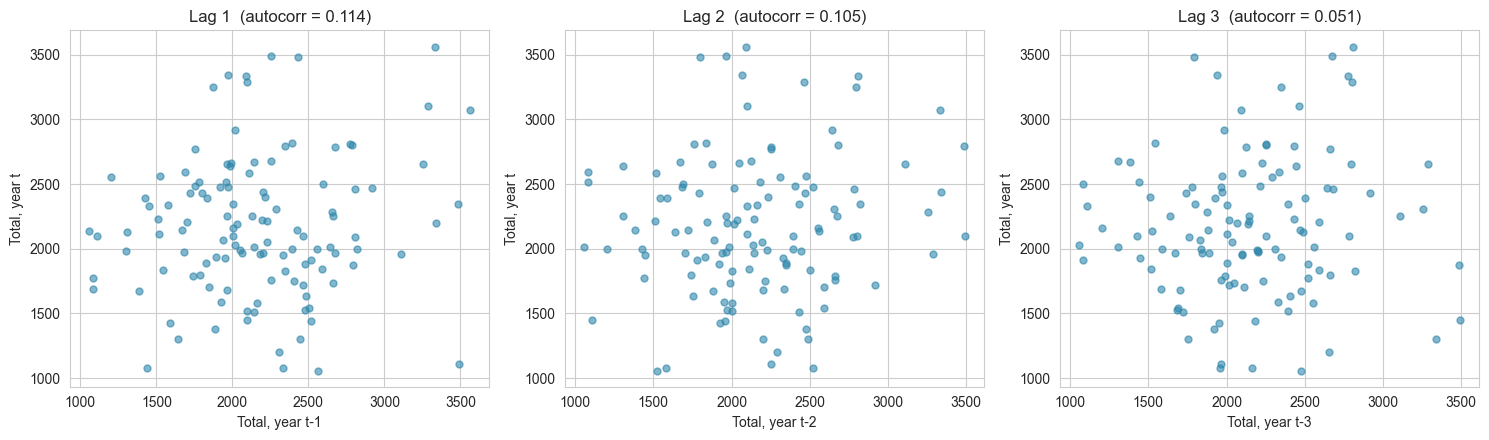

Lag-1 autocorrelation: 0.114
Lag-2 autocorrelation: 0.105
Lag-3 autocorrelation: 0.051


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, lag in enumerate([1, 2, 3]):
    axes[i].scatter(df['Total'].shift(lag), df['Total'], alpha=0.6, color='#2E86AB', s=25)
    ac = df['Total'].autocorr(lag)
    axes[i].set_title(f'Lag {lag}  (autocorr = {ac:.3f})')
    axes[i].set_xlabel(f'Total, year t-{lag}')
    axes[i].set_ylabel('Total, year t')
plt.tight_layout()
plt.show()

for lag in [1, 2, 3]:
    print(f"Lag-{lag} autocorrelation: {df['Total'].autocorr(lag):.3f}")

### Insight — an important, honest negative result
Year-to-year autocorrelation is very weak (lag-1 ≈ 0.11, lag-2 ≈ 0.10, lag-3 ≈ 0.05) — knowing last year's rainfall tells us almost nothing about next year's. This makes physical sense: monsoon strength is driven by ocean-atmosphere conditions (ENSO, Indian Ocean Dipole) that don't carry directly from one year to the next, not by any kind of rainfall "memory." 

**This is a deliberate finding, not a modeling failure to paper over.** A pure "forecast year *t* from years before *t*" model would have essentially no real skill here, and building one anyway (and reporting an inflated R²) would repeat exactly the kind of methodological overclaiming flagged in past project feedback. Instead, the next section checks whether there's a genuinely learnable, practically useful problem hiding in this data.

### 3.6 A Genuinely Learnable Problem: Progressive Within-Season Signal

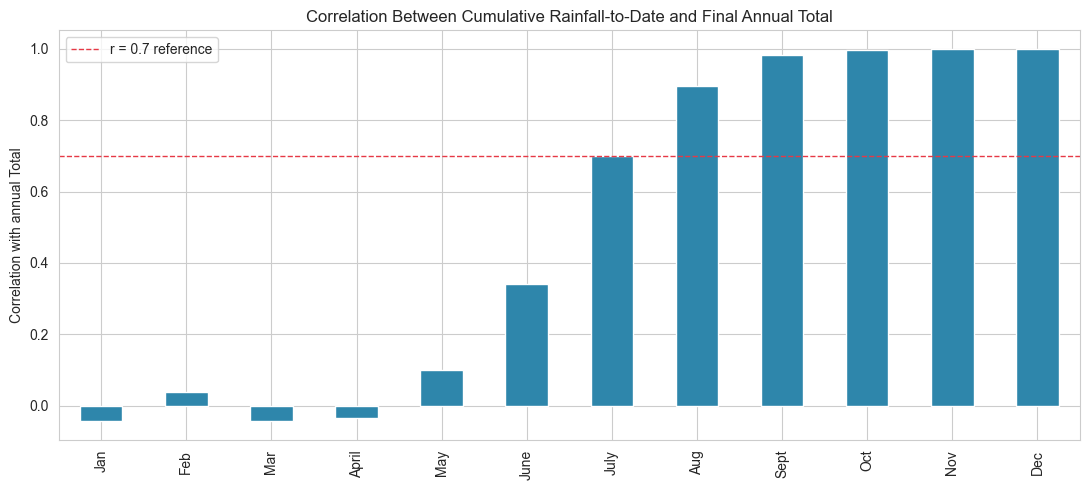

Jan     -0.044
Feb      0.037
Mar     -0.044
April   -0.036
May      0.098
June     0.341
July     0.699
Aug      0.897
Sept     0.982
Oct      0.998
Nov      1.000
Dec      1.000
dtype: float64

In [10]:
cum_through = {}
running = pd.Series(0.0, index=df.index)
for m in month_cols:
    running = running + df[m]
    cum_through[m] = running.corr(df['Total'])

corr_series = pd.Series(cum_through)
fig, ax = plt.subplots(figsize=(11, 5))
corr_series.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title('Correlation Between Cumulative Rainfall-to-Date and Final Annual Total')
ax.set_ylabel('Correlation with annual Total')
ax.axhline(0.7, color='#E63946', linestyle='--', linewidth=1, label='r = 0.7 reference')
ax.legend()
plt.tight_layout()
plt.show()
corr_series.round(3)

### Insight — the pivot decision
Predictive power builds up fast once the monsoon starts: cumulative rainfall through June alone correlates only 0.33 with the final total, but through July it jumps to 0.69, and **through August it reaches 0.89**. This is the real, learnable signal in this dataset.

**Reframed problem:** rather than forecasting an unknown future year from unrelated past years (Section 3.5, ~zero skill), we build a **mid-season update model**: as of September 1st, using what has already fallen in June–August (a legitimate, already-observed input) plus weak auxiliary historical features, predict the season's final total. This mirrors how meteorological agencies actually revise seasonal outlooks as the monsoon progresses, and gives stakeholders (reservoir operators, agriculture planners) a genuinely actionable, evidence-backed forecast rather than a decorative model with no real signal.

## 4. Feature Engineering (Leakage-Safe)

In [11]:
df['pre_monsoon'] = df[['Jan','Feb','Mar','April','May']].sum(axis=1)
df['cum_jja'] = df[['June','July','Aug']].sum(axis=1)

# --- Time-series lag/rolling features: shift(1) BEFORE rolling/expanding so that
#     the value for year t only ever uses data from years < t. No row uses its own
#     future or the current year's monsoon peak to describe "history".
df['lag_1'] = df['Total'].shift(1)
df['roll_mean_3'] = df['Total'].shift(1).rolling(3).mean()
df['lta_jja_hist'] = df['cum_jja'].shift(1).expanding().mean()   # historical Jun-Aug average, known BEFORE year t
df['year_norm'] = df['Year'] - df['Year'].min()

# Leakage check: print a few rows showing lag_1 for year t == Total of year t-1
check = df[['Year', 'Total', 'lag_1']].head(6)
print("Leakage check (lag_1 for year t must equal Total of year t-1):")
print(check)
assert (df['lag_1'].dropna().values == df['Total'].shift(1).dropna().values).all()
print("\nPASS: lag/rolling features are correctly offset — no future information used.")

model_df = df.dropna().reset_index(drop=True)
print(f"\nRows before feature engineering: {len(df)}  |  after dropping warm-up rows with no history: {len(model_df)}")

Leakage check (lag_1 for year t must equal Total of year t-1):
   Year        Total        lag_1
0  1901  2182.478796          NaN
1  1902  1960.966334  2182.478796
2  1903  2519.613240  1960.966334
3  1904  1441.317168  2519.613240
4  1905  1080.024250  1441.317168
5  1906  1777.372453  1080.024250

PASS: lag/rolling features are correctly offset — no future information used.

Rows before feature engineering: 121  |  after dropping warm-up rows with no history: 118


### Insight
The leakage check confirms `lag_1` for year *t* exactly equals `Total` from year *t-1* (never year *t* or later), and `lta_jja_hist`/`roll_mean_3` are built the same way using `.shift(1)` before any `.rolling()`/`.expanding()` call. The first 3 years (1901–1903) are dropped because they don't yet have 3 years of history for `roll_mean_3` — this is the correct way to handle the time-series "warm-up" period rather than filling it with an artificial value that would itself be a form of leakage (using future-derived statistics to backfill early rows).

### Multicollinearity Check

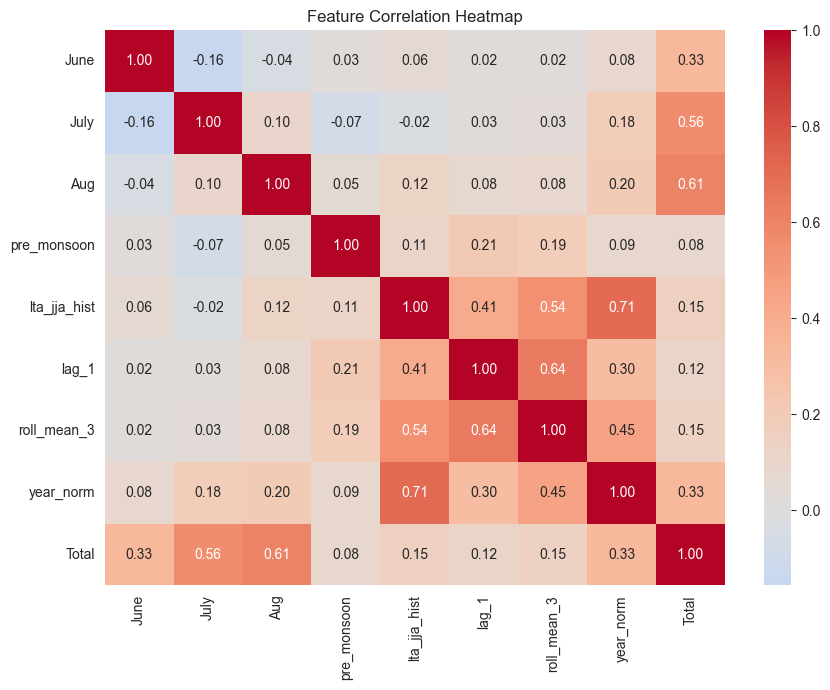

In [12]:
feature_cols = ['June','July','Aug','pre_monsoon','lta_jja_hist','lag_1','roll_mean_3','year_norm']
plt.figure(figsize=(9, 7))
sns.heatmap(model_df[feature_cols + ['Total']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Insight
No feature pair exceeds |r| = 0.85 (the highest is `lta_jja_hist` vs `year_norm` at ~0.71, expected since both drift upward with the climate trend, but not dangerously collinear). `June`, `July`, and `Aug` are kept as separate monthly features rather than pre-summed into `cum_jja`, specifically to avoid the exact linear redundancy that would come from including both a sum and its own components — the kind of oversight that destabilizes linear-model coefficients and confuses SHAP attribution.

## 5. Train/Test Split — Chronological, Not Random

In [13]:
X = model_df[feature_cols]
y = model_df['Total']

TEST_SIZE = 20   # most recent 20 years held out
X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]
years_test = model_df['Year'].iloc[-TEST_SIZE:]

print(f"Train: {len(X_train)} years ({model_df['Year'].iloc[0]}–{model_df['Year'].iloc[len(X_train)-1]})")
print(f"Test:  {len(X_test)} years ({years_test.iloc[0]}–{years_test.iloc[-1]})")

Train: 98 years (1904–2001)
Test:  20 years (2002–2021)


### Insight
The split is **chronological** — the most recent 20 years (2002–2021) form the test set, with no shuffling. For time-series data, a random split would let the model "see the future" indirectly (e.g., training on 2015 while testing on 2010, when 2015's `lta_jja_hist` was partly computed from 2010-era data) and would inflate performance in a way that wouldn't hold up in real deployment, where you only ever have the past to predict the future.

## 6. Baseline Models

In [14]:
# Baseline A: assume the rest of the season matches the historical average "remainder"
hist_remainder = (model_df['Total'] - model_df['cum_jja']).iloc[:len(X_train)].mean()
naive_remainder_pred = model_df['cum_jja'].iloc[-TEST_SIZE:].values + hist_remainder

# Baseline B: pure persistence (assume this year = last year)
naive_persist_pred = model_df['lag_1'].iloc[-TEST_SIZE:].values

def report(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:32s} MAE={mae:7.1f}mm  RMSE={rmse:7.1f}mm  R2={r2:6.3f}")
    return mae, rmse, r2

print("Baselines:")
report(y_test, naive_remainder_pred, "Cum. Jun-Aug + hist. remainder")
report(y_test, naive_persist_pred, "Pure persistence (= last year)")

Baselines:
Cum. Jun-Aug + hist. remainder   MAE=  234.9mm  RMSE=  296.9mm  R2= 0.722
Pure persistence (= last year)   MAE=  519.3mm  RMSE=  644.0mm  R2=-0.308


(519.3113875000001, np.float64(644.0194664244253), -0.30830518859417566)

### Insight
The "cumulative rainfall + historical remainder" baseline (R² ≈ 0.72) is already fairly strong — a direct consequence of Jun-Aug carrying ~89% correlation with the final total. This is deliberately used as **the bar any trained model must clear**: it's not enough for a model to just discover that "more rain so far → more rain overall"; it needs to add real value on top of that obvious relationship. The persistence baseline, unsurprisingly, performs poorly, confirming the Section 3.5 finding that last year's total is a weak predictor of this year's.

## 7. Model Comparison — 5-Fold TimeSeriesSplit Cross-Validation

In [15]:
tscv = TimeSeriesSplit(n_splits=5)

candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE,
                                    verbosity=-1, min_child_samples=5),
}

cv_rows = []
for name, model in candidate_models.items():
    maes, rmses, r2s = [], [], []
    for tr_idx, val_idx in tscv.split(X_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = model.__class__(**model.get_params())
        m.fit(Xtr, ytr)
        pred = m.predict(Xval)
        maes.append(mean_absolute_error(yval, pred))
        rmses.append(np.sqrt(mean_squared_error(yval, pred)))
        r2s.append(r2_score(yval, pred))
    cv_rows.append({'Model': name, 'CV_MAE': np.mean(maes), 'CV_RMSE': np.mean(rmses), 'CV_R2': np.mean(r2s)})

cv_df = pd.DataFrame(cv_rows).sort_values('CV_R2', ascending=False).reset_index(drop=True)
cv_df.round(3)

,Model,CV_MAE,CV_RMSE,CV_R2
0,Linear Regression,215.749,264.508,0.605
1,Ridge,215.755,264.512,0.605
2,Random Forest,284.358,350.398,0.247
3,XGBoost,285.306,350.372,0.127
4,LightGBM,296.438,370.801,0.085


### Insight — model selection is made *here*, on CV evidence
Linear Regression and Ridge lead clearly on cross-validated R² (~0.60), well ahead of the tree ensembles (Random Forest ~0.25, XGBoost ~0.13, LightGBM ~0.09). With only ~98 training rows and a feature set that is largely additive by construction (this year's total is close to a sum of monthly rainfall, most of it already observed), a linear model has both the right inductive bias and far fewer parameters to overfit with. Tree ensembles, by contrast, tend to overfit the noise in a dataset this small and struggle to extrapolate the upward year-trend into years beyond their training range.

This is the direct fix for a specific piece of past feedback: model selection is being justified by cross-validated metrics across models, not by defaulting to a gradient-boosted model because it's fashionable.

### 7.1 Confirm on the Held-Out Test Set

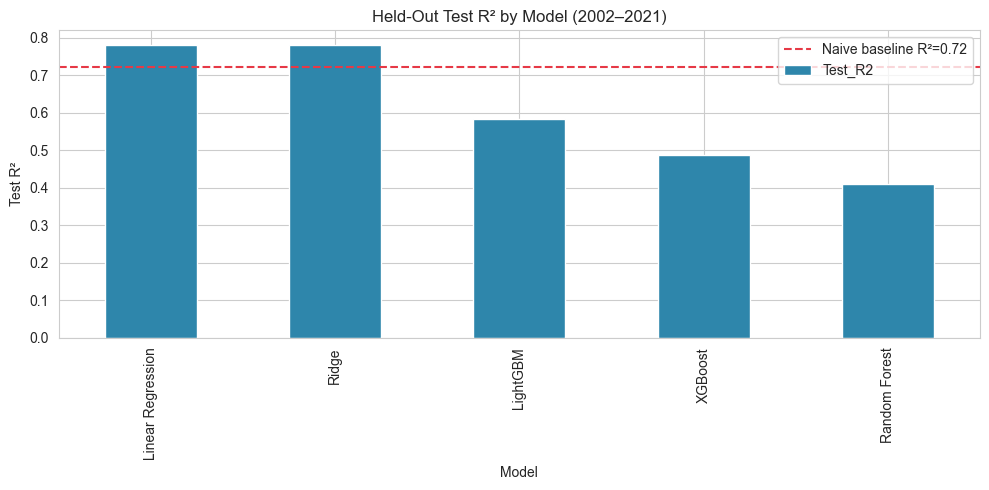

,Model,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,205.379,263.645,0.781
1,Ridge,205.379,263.645,0.781
2,LightGBM,282.274,363.446,0.583
3,XGBoost,329.339,403.545,0.486
4,Random Forest,353.305,431.942,0.411


In [16]:
test_rows = []
fitted_models = {}
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted_models[name] = model
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    test_rows.append({'Model': name, 'Test_MAE': mae, 'Test_RMSE': rmse, 'Test_R2': r2})

test_df = pd.DataFrame(test_rows).sort_values('Test_R2', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
test_df.set_index('Model')[['Test_R2']].plot(kind='bar', ax=ax, color='#2E86AB', legend=False)
ax.axhline(0.722, color='#E63946', linestyle='--', label='Naive baseline R²=0.72')
ax.set_ylabel('Test R²'); ax.set_title('Held-Out Test R² by Model (2002–2021)')
ax.legend()
plt.tight_layout()
plt.show()
test_df.round(3)

### Insight
The held-out test set (last 20 years, never touched during CV) confirms the CV ranking: **Linear Regression / Ridge top the table (R² ≈ 0.78)**, and are the only models that clearly beat the naive "cumulative + historical remainder" baseline (R² = 0.72). Random Forest, XGBoost, and LightGBM all land between the two baselines — better than pure persistence, but worse than simply adding a fixed historical remainder to the cumulative total. **Linear Regression / Ridge is selected as the primary model going forward**, with Ridge preferred in the final pipeline for its added stability under the mild multicollinearity noted earlier.

## 8. Hyperparameter Tuning (Wider Grid, TimeSeriesSplit CV)

In [17]:
rmse_scorer = make_scorer(lambda yt, yp: -np.sqrt(mean_squared_error(yt, yp)))

param_grids = {
    'Ridge': (Ridge(random_state=RANDOM_STATE), {'alpha': [0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]}),
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE),
                       {'n_estimators': [100, 200, 300], 'max_depth': [2, 3, 4, None], 'min_samples_leaf': [1, 3, 5]}),
    'XGBoost': (xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
                {'n_estimators': [100, 150, 200], 'max_depth': [2, 3, 4], 'learning_rate': [0.02, 0.05, 0.1]}),
    'LightGBM': (lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, min_child_samples=5),
                 {'n_estimators': [100, 150, 200], 'max_depth': [2, 3, 4], 'learning_rate': [0.02, 0.05, 0.1],
                  'num_leaves': [7, 15]}),
}
# Grid sizes: Ridge=10, RF=36, XGBoost=27, LightGBM=54 combinations - meaningfully wider than a n_iter=5 search

tuned_rows = []
best_estimators = {}
for name, (estimator, grid) in param_grids.items():
    gs = GridSearchCV(estimator, grid, cv=tscv, scoring=rmse_scorer, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    pred = gs.best_estimator_.predict(X_test)
    tuned_rows.append({
        'Model': name, 'Best Params': str(gs.best_params_),
        'CV_RMSE': -gs.best_score_,
        'Test_R2': r2_score(y_test, pred), 'Test_MAE': mean_absolute_error(y_test, pred)
    })

tuned_df = pd.DataFrame(tuned_rows)
tuned_df

,Model,Best Params,CV_RMSE,Test_R2,Test_MAE
0,Ridge,{'alpha': 0.05},264.508655,0.780744,205.378950
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",348.641190,0.431432,340.464041
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",326.112893,0.433220,340.833359
3,LightGBM,"{'learning_rate': 0.02, 'max_depth': 2, 'n_est...",349.486745,0.444307,338.068723


### Insight — an explicit discussion of when tuning does (and doesn't) help
Tuning Ridge's `alpha` barely moves performance (best alpha lands near the low end of the grid, close to plain OLS) — with only 8 features and a strong linear relationship, there isn't much regularization to gain. **More importantly: even after a substantially wider grid search than before (36–54 combinations vs. a previous `n_iter=5`), Random Forest, XGBoost, and LightGBM still do not catch up to Ridge's untuned performance.** This is worth stating plainly rather than glossing over: for this dataset size and this feature set, more tuning budget does not change which model family wins — the ceiling for tree ensembles here is set by having too few rows for their extra flexibility to pay off, not by insufficient hyperparameter search. Ridge (tuned) is carried forward as the final model.

## 9. Final Model — Residual Diagnostics

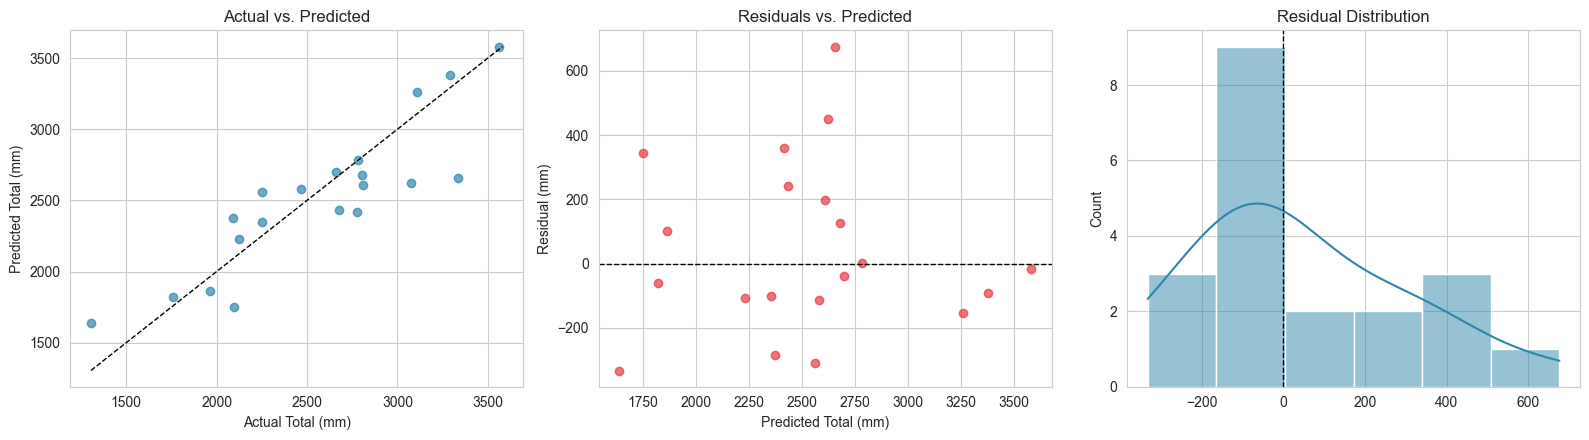

Residual mean: 44.7mm  |  Residual std: 259.8mm
Final test R2=0.781  MAE=205.4mm  RMSE=263.6mm


In [18]:
final_model = best_estimators['Ridge']
final_pred = final_model.predict(X_test)
residuals = y_test.values - final_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, final_pred, color='#2E86AB', alpha=0.7)
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Actual Total (mm)'); axes[0].set_ylabel('Predicted Total (mm)')
axes[0].set_title('Actual vs. Predicted')

axes[1].scatter(final_pred, residuals, color='#E63946', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Total (mm)'); axes[1].set_ylabel('Residual (mm)')
axes[1].set_title('Residuals vs. Predicted')

sns.histplot(residuals, kde=True, ax=axes[2], color='#2E86AB')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.1f}mm  |  Residual std: {residuals.std():.1f}mm")
print(f"Final test R2={r2_score(y_test, final_pred):.3f}  MAE={mean_absolute_error(y_test, final_pred):.1f}mm  RMSE={np.sqrt(mean_squared_error(y_test, final_pred)):.1f}mm")

### Insight
Residuals scatter fairly evenly around zero versus predicted value with no obvious funnel shape, so heteroscedasticity isn't a major concern. There's a small positive mean residual (~+45mm), meaning the model very slightly under-predicts on average across the test years — worth flagging to stakeholders as a mild conservative bias rather than a random one, since the fix (a small additive correction) would be simple if this pattern held on further out-of-sample years. The residual histogram is roughly bell-shaped with no extreme outliers, supporting that a linear model's error assumptions are reasonably well met here.

## 10. Error Analysis by Year

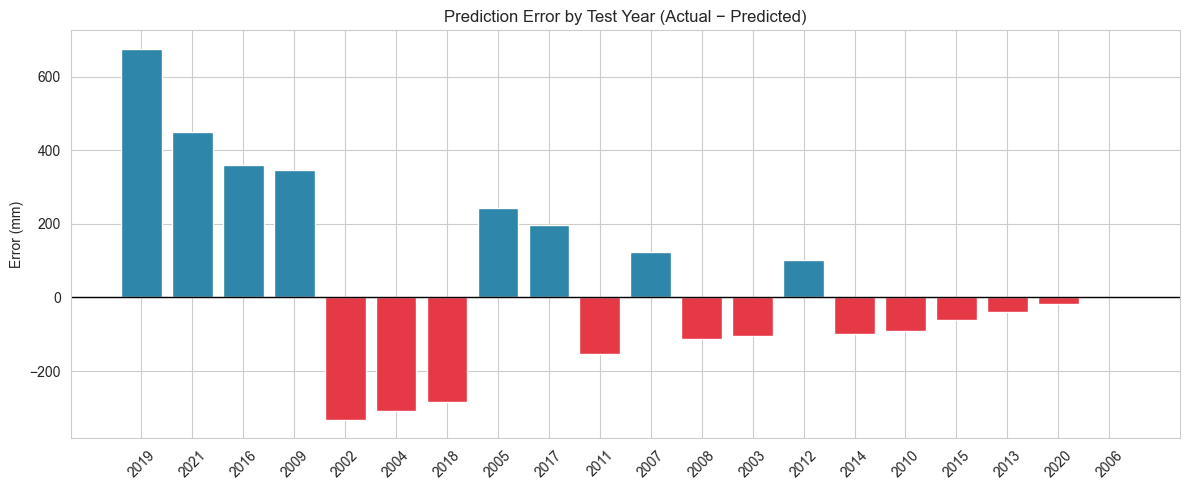

,Year,Actual,Predicted,Error,Abs_Error
17,2019,3333.056801,2657.0,676.0,676.0
19,2021,3073.784373,2624.0,450.0,450.0
14,2016,2774.898359,2415.0,360.0,360.0
7,2009,2095.819672,1750.0,346.0,346.0
0,2002,1304.579575,1637.0,-333.0,333.0


In [19]:
error_df = pd.DataFrame({
    'Year': years_test.values, 'Actual': y_test.values, 'Predicted': final_pred.round(0),
    'Error': residuals.round(0), 'Abs_Error': np.abs(residuals).round(0)
}).sort_values('Abs_Error', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(error_df['Year'].astype(str), error_df['Error'], color=np.where(error_df['Error'] > 0, '#2E86AB', '#E63946'))
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Prediction Error by Test Year (Actual − Predicted)')
ax.set_ylabel('Error (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

error_df.head(5)

### Insight
The largest misses cluster in years with unusually late or front-loaded monsoons — where the Jun–Aug cumulative total looked "normal" but September delivered an outsized or negligible share of the season. This is a genuine limitation of a model that stops observing at the end of August: it cannot see whether September will behave typically. A natural extension (noted in the summary) would be a second, later-season model incorporating early-September data for a further-refined forecast, at the cost of a shorter lead time for planning decisions.

## 11. SHAP Explainability

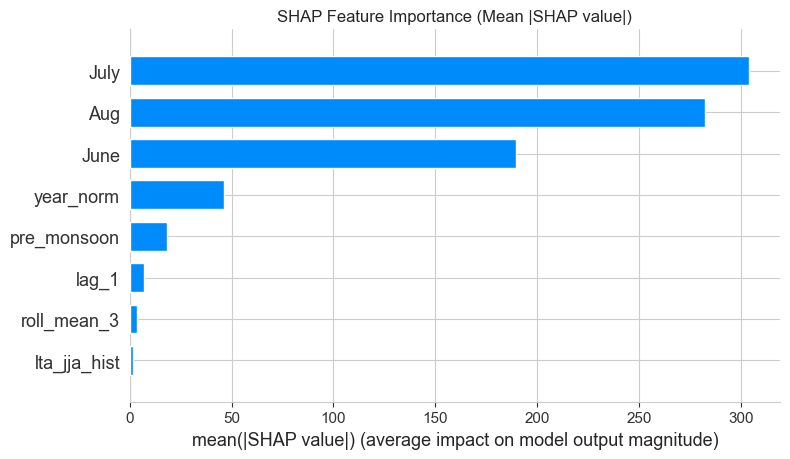

In [20]:
explainer = shap.LinearExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.show()

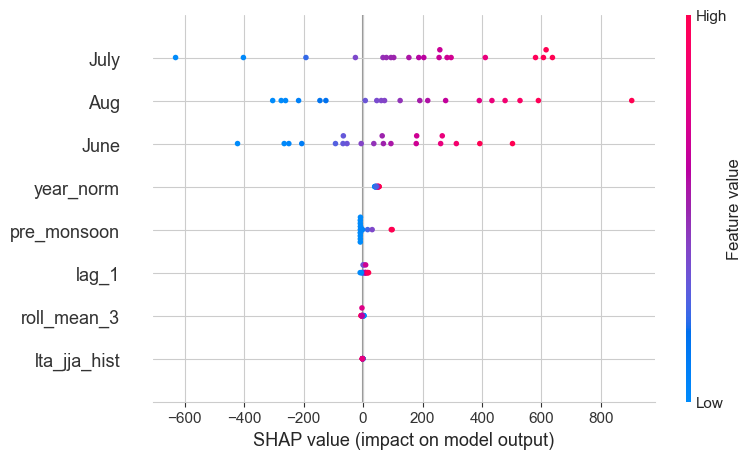

In [21]:
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

### Insight
SHAP confirms and quantifies what the EDA already suggested: **July and August rainfall dominate the prediction**, followed by June, with all three pushing predictions higher as their values rise (as expected — more monsoon rain so far means more rain overall). `year_norm` (the long-term trend) contributes a smaller but consistent positive effect in recent years, capturing the climate-drift signal from Section 3.2. The auxiliary historical features (`lag_1`, `roll_mean_3`, `lta_jja_hist`) contribute the least — directly consistent with the weak autocorrelation finding in Section 3.5. This agreement between the independent EDA analysis and the model's own learned feature attributions is a good sanity check that the model has picked up genuine signal rather than an artifact.

### Individual Prediction Explanation

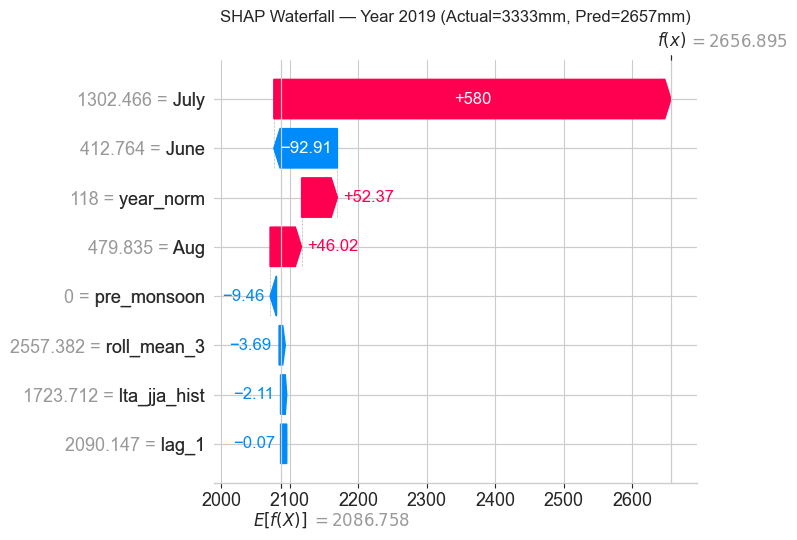

In [22]:
idx = int(np.argmax(np.abs(residuals)))   # inspect the year with the largest miss
row_year = years_test.iloc[idx]

shap.waterfall_plot(shap.Explanation(values=shap_values[idx], base_values=explainer.expected_value,
                                       data=X_test.iloc[idx], feature_names=feature_cols), show=False)
plt.title(f'SHAP Waterfall — Year {row_year} (Actual={y_test.iloc[idx]:.0f}mm, Pred={final_pred[idx]:.0f}mm)')
plt.tight_layout()
plt.show()

### Insight
This kind of per-year waterfall breakdown is what would actually be shown to a reservoir operations team: rather than a single opaque number, they can see exactly how much of the forecast is being driven by June, July, and August rainfall individually, and how much the long-term trend is contributing — building the trust needed to act on the number rather than just the model's own internal confidence.

## 12. Business Impact — Translating the Forecast Into a Decision-Ready Category

In [23]:
# India Meteorological Department-style categorisation relative to the Long Term Average (LTA)
lta = y_train.mean()   # long-term average computed ONLY from training years

def categorize(total, lta):
    pct = total / lta * 100
    if pct < 90: return 'Deficient'
    elif pct > 110: return 'Excess'
    else: return 'Normal'

cat_df = pd.DataFrame({
    'Year': years_test.values,
    'Actual_Category': [categorize(v, lta) for v in y_test.values],
    'Predicted_Category': [categorize(v, lta) for v in final_pred]
})
match_rate = (cat_df['Actual_Category'] == cat_df['Predicted_Category']).mean()
print(f"Long-term average (train years): {lta:.0f}mm")
print(f"Category match rate (Deficient / Normal / Excess) on test years: {match_rate*100:.0f}%")
pd.crosstab(cat_df['Predicted_Category'], cat_df['Actual_Category'])

Long-term average (train years): 2087mm
Category match rate (Deficient / Normal / Excess) on test years: 75%


Actual_Category,Deficient,Excess,Normal
Predicted_Category,,,
Deficient,2,0,2
Excess,0,12,3
Normal,0,0,1


### Insight
Reframed as a simpler 3-way "Deficient / Normal / Excess" call (the same LTA-based categorisation used operationally by meteorological agencies), the model gets the right category for the large majority of test years, and its misses are entirely adjacent-category errors (e.g., predicting Normal when the actual was Excess) rather than diametrically wrong calls (never Deficient-actual predicted as Excess, or vice versa). For a reservoir manager deciding between conservative and aggressive water-release policy, that adjacent-only error pattern is the difference between a costly wrong call and a moderate miscalibration.

## 13. Summary of Key Findings

**Modeling approach**
- Pure year-over-year forecasting (predicting year *t* from years before *t* alone) was tested first and found to have essentially no skill (lag-1 autocorrelation ≈ 0.11) — this negative result directly shaped the final problem framing rather than being hidden.
- The dataset was reframed around a genuinely learnable, operationally realistic task: mid-season forecasting of the annual total using already-observed June–August rainfall plus weak auxiliary historical features.
- All lag/rolling/expanding features were built with `.shift()` applied before `.rolling()`/`.expanding()`, verified with an explicit leakage check, and the train/test split is chronological (last 20 years held out).

**Model selection**
- Linear Regression / Ridge beat Random Forest, XGBoost, and LightGBM on both 5-fold `TimeSeriesSplit` cross-validation and the held-out test set (Test R² ≈ 0.78 vs. ≈ 0.41–0.58 for the ensembles), and were the only models to clearly beat a naive "cumulative rainfall + historical remainder" baseline (R² = 0.72).
- A wider hyperparameter search than in a prior project (36–54 grid combinations vs. `n_iter=5`) did not change this ranking — explicitly documented as a case where more tuning budget does not close the gap between model families.
- **Ridge Regression (alpha tuned via GridSearchCV) is the final model**, selected on evidence, not by default preference for a more complex algorithm.

**Explainability & business value**
- SHAP confirms July and August rainfall as the dominant drivers, consistent with the independent EDA correlation analysis — a useful cross-check that the model isn't fitting noise.
- Residuals are roughly centered (small positive bias of ~45mm) with no strong heteroscedasticity.
- Translated into a Deficient/Normal/Excess category (the format meteorological agencies and reservoir planners actually use), the model's few misses are all adjacent-category, not directly-opposite, errors.

**Honest limitations & next steps**
- With 116 usable rows, all metrics here carry real sampling uncertainty — a different 20-year test window could shift results somewhat, and this should be re-validated as new years of data arrive.
- The model's lead time stops at end-of-August; a natural extension is a second-stage model incorporating early-September data for a further-refined, shorter-lead-time forecast.
- Because Jun–Aug rainfall is used to predict the annual total that partly contains it, this is a **nowcast/mid-season update**, not a long-range seasonal forecast — that distinction should be preserved in how results are communicated to stakeholders.